# Mapa del delito del mes de abril del año 2023

Descripción:
    En este notebook se realizó la construcción, mediante los datos poscionales, un mapa del delito correspondiente al mes de abril del año 2023. Se implementó el uso de la librería geopandas.

## Importación de librerías

- Pandas: especializada en el manejo y analisís de estructuras de datos.
- Geopandas: especializada en el manejo de datos geoespaciales.
- Matplotlib: especializada en el manejo fundamental de visualización de datos.
- Contextily: especializada en el manejo de mapas base.

In [1]:
#Install contextily and geopandas
!pip install contextily --upgrade
!pip install geopandas

import pandas as pd #Import pandas
import geopandas as gpd #Import geopandas
import matplotlib.pyplot as plt #Import matplotlib
import contextily as ctx #Import contextily

## Cargar archivo en formato CSV (dataset)

In [2]:
url_dataset = "https://raw.githubusercontent.com/gmmorales/ifts24-data-science-datasets/refs/heads/master/datasets/modelizado-de-sistemas-de-ia/integrador/dataset_clean.csv"
df = pd.read_csv(url_dataset)

## Exploración general del conjunto de datos

### Tamaño y tipo de datos (Shape and Types)

In [3]:
print("Filas y columnas:\n") #show rows and columns
df.shape

Filas y columnas:



(152739, 15)

In [4]:
#Show datatype
print("\nTipos de Dato\n")
print(df.dtypes)


Tipos de Dato

id-mapa      int64
anio         int64
mes         object
dia         object
fecha       object
franja       int64
tipo        object
subtipo     object
uso_arma    object
uso_moto    object
barrio      object
comuna       int64
latitud     object
longitud    object
cantidad     int64
dtype: object


### Nombres de las columnas o encabezados y registros

In [5]:
df.head(0) #show headers names

,id-mapa,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad


In [6]:
df.head(3) #Show headers names and records

,id-mapa,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad
0,1114988,2023,NOVIEMBRE,JUEVES,30/11/2023,17,Amenazas,Amenazas,NO,NO,BOCA,4,-34.625.121,-58.348.646,1
1,1114989,2023,NOVIEMBRE,JUEVES,30/11/2023,17,Amenazas,Amenazas,NO,NO,BOCA,4,-34.625.121,-58.348.646,1
2,1114990,2023,NOVIEMBRE,JUEVES,30/11/2023,17,Amenazas,Amenazas,NO,NO,BOCA,4,-34.625.121,-58.348.646,1


In [7]:
df.tail() #Show the last records

,id-mapa,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad
152734,1399607,2023,NOVIEMBRE,MARTES,21/11/2023,0,Homicidios,Homicidios dolosos,NO,NO,BELGRANO,13,-34.562.634,-58.454.886,1
152735,1399608,2023,NOVIEMBRE,SABADO,25/11/2023,3,Homicidios,Homicidios dolosos,NO,NO,BALVANERA,3,-34.619.149,-5.840.504,1
152736,1399609,2023,DICIEMBRE,VIERNES,1/12/2023,14,Homicidios,Homicidios dolosos,NO,NO,PARQUE CHACABUCO,7,-34.647.346,-58.437.424,1
152737,1399610,2023,DICIEMBRE,DOMINGO,24/12/2023,17,Homicidios,Homicidios dolosos,NO,NO,BALVANERA,3,-34.610.116,-58.405.971,1
152738,1399611,2023,DICIEMBRE,DOMINGO,31/12/2023,7,Homicidios,Homicidios dolosos,NO,NO,FLORES,7,-34.636.535,-58.466.927,1


## Distribución geográfica de los delitos ocurridos

Cantidad de registros encontrados para Abril de 2023: 12294 filas.


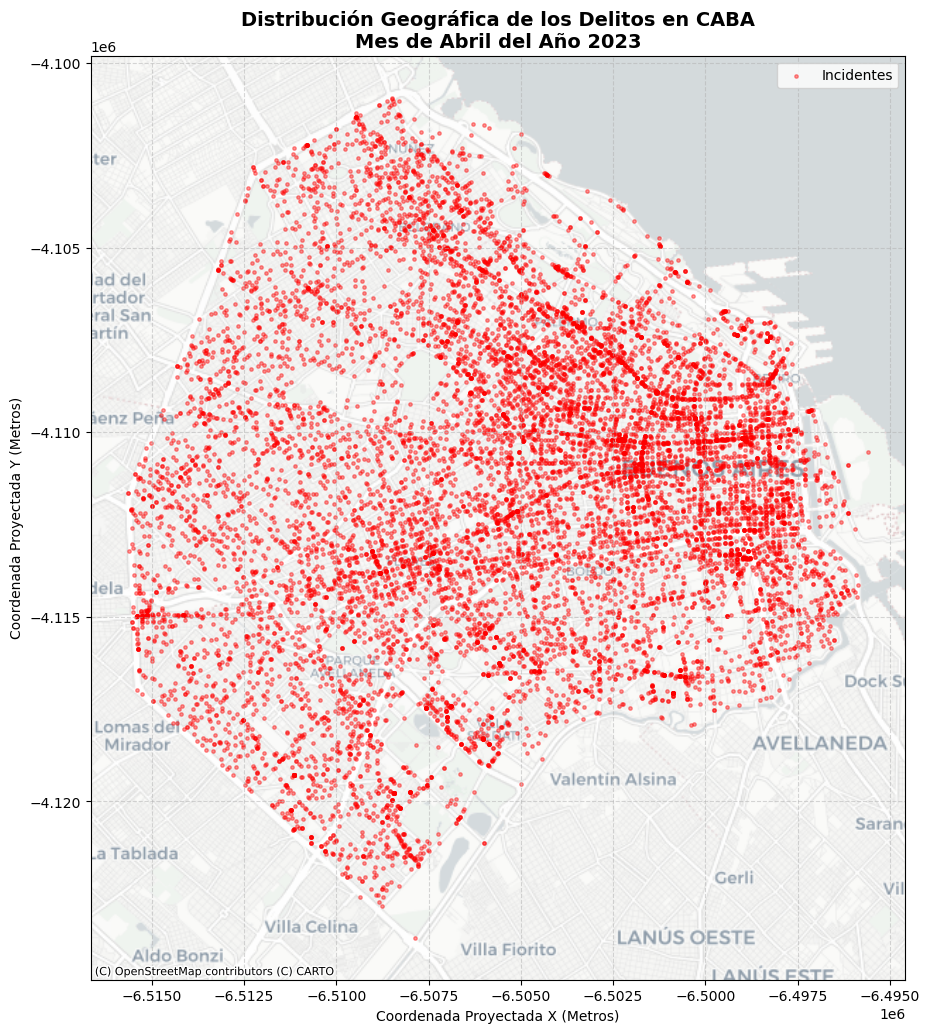

In [8]:
# ==============================================================================
# 1. LIMPIEZA CRÍTICA DE COORDENADAS (Corrección de formato de texto a decimal)
# ==============================================================================
# El archivo original interpreta las coordenadas como texto con puntos (ej: -34.625.121).
# Removemos los puntos y forzamos la inserción del punto decimal en el lugar correcto.
df['latitud'] = df['latitud'].astype(str).str.replace('.', '', regex=False)
df['longitud'] = df['longitud'].astype(str).str.replace('.', '', regex=False)

# Re-localizamos el punto decimal matemático (después del segundo dígito para coordenadas de Bs. As.)
df['latitud'] = df['latitud'].apply(lambda x: float(x[:3] + '.' + x[3:]) if x != '0' and len(x) > 3 else 0.0)
df['longitud'] = df['longitud'].apply(lambda x: float(x[:3] + '.' + x[3:]) if x != '0' and len(x) > 3 else 0.0)

# Filtramos filas con coordenadas nulas o inconsistentes en cero
df = df.dropna(subset=['latitud', 'longitud'])
df = df[(df['latitud'] != 0) & (df['longitud'] != 0)]

# ==============================================================================
# 2. TRATAMIENTO DE FECHAS Y FILTRADO TEMPORAL (Abril de 2023)
# ==============================================================================
# Agregamos dayfirst=True para evitar el Warning de orden Día/Mes/Año
df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True)

# filtro para el año 2023 y el mes de abril
df_abril_2023 = df[(df['fecha'].dt.year == 2023) & (df['fecha'].dt.month == 4)]

print(f"Cantidad de registros encontrados para Abril de 2023: {len(df_abril_2023)} filas.")

# ==============================================================================
# 3. CONVERSIÓN A GEODATAFRAME Y CAMBIO DE SISTEMA DE COORDENADAS (CRS)
# ==============================================================================
# Creamos el objeto geoespacial vinculando las columnas numéricas como puntos geométricos
gdf_abril_2023 = gpd.GeoDataFrame(
    df_abril_2023, 
    geometry=gpd.points_from_xy(df_abril_2023['longitud'], df_abril_2023['latitud'])
)

# Asignamos el sistema de referencia geográfico estándar WGS84
gdf_abril_2023.crs = "EPSG:4326"

# Convertimos al sistema proyectado Web Mercator (EPSG:3857). 
# Esto es obligatorio para que coincida matemáticamente con las imágenes de Contextily.
gdf_abril_2023 = gdf_abril_2023.to_crs(epsg=3857)

# ==============================================================================
# 4. GENERACIÓN DEL GRÁFICO Y MAPA DE FONDO
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 12))

# Graficamos los delitos. Usamos alpha=0.4 para dar transparencia y visualizar la densidad ("hotspots")
gdf_abril_2023.plot(ax=ax, marker='o', color='red', markersize=6, alpha=0.4, label='Incidentes')

# Agregamos el mapa base de CartoDB (estilo Positron, ideal por su fondo claro y limpio)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Configuraciones estéticas finales
plt.title("Distribución Geográfica de los Delitos en CABA\nMes de Abril del Año 2023", fontsize=14, fontweight='bold')
plt.xlabel('Coordenada Proyectada X (Metros)')
plt.ylabel('Coordenada Proyectada Y (Metros)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Mostramos el mapa integrado
plt.show()